# 1. Data Import 

In [1]:
import pandas as pd
df=pd.read_csv(r"C:\Users\karna\Downloads\Bank_Transaction_Fraud_Detection.csv")


In [2]:
df.head()

,Customer_ID,Customer_Name,Gender,Age,State,City,Bank_Branch,Account_Type,Transaction_ID,Transaction_Date,...,Merchant_Category,Account_Balance,Transaction_Device,Transaction_Location,Device_Type,Is_Fraud,Transaction_Currency,Customer_Contact,Transaction_Description,Customer_Email
0,d5f6ec07-d69e-4f47-b9b4-7c58ff17c19e,Osha Tella,Male,60,Kerala,Thiruvananthapuram,Thiruvananthapuram Branch,Savings,4fa3208f-9e23-42dc-b330-844829d0c12c,23-01-2025,...,Restaurant,74557.27,Voice Assistant,"Thiruvananthapuram, Kerala",POS,0,INR,+9198579XXXXXX,Bitcoin transaction,oshaXXXXX@XXXXX.com
1,7c14ad51-781a-4db9-b7bd-67439c175262,Hredhaan Khosla,Female,51,Maharashtra,Nashik,Nashik Branch,Business,c9de0c06-2c4c-40a9-97ed-3c7b8f97c79c,11-01-2025,...,Restaurant,74622.66,POS Mobile Device,"Nashik, Maharashtra",Desktop,0,INR,+9191074XXXXXX,Grocery delivery,hredhaanXXXX@XXXXXX.com
2,3a73a0e5-d4da-45aa-85f3-528413900a35,Ekani Nazareth,Male,20,Bihar,Bhagalpur,Bhagalpur Branch,Savings,e41c55f9-c016-4ff3-872b-cae72467c75c,25-01-2025,...,Groceries,66817.99,ATM,"Bhagalpur, Bihar",Desktop,0,INR,+9197745XXXXXX,Mutual fund investment,ekaniXXX@XXXXXX.com
3,7902f4ef-9050-4a79-857d-9c2ea3181940,Yamini Ramachandran,Female,57,Tamil Nadu,Chennai,Chennai Branch,Business,7f7ee11b-ff2c-45a3-802a-49bc47c02ecb,19-01-2025,...,Entertainment,58177.08,POS Mobile App,"Chennai, Tamil Nadu",Mobile,0,INR,+9195889XXXXXX,Food delivery,yaminiXXXXX@XXXXXXX.com
4,3a4bba70-d9a9-4c5f-8b92-1735fd8c19e9,Kritika Rege,Female,43,Punjab,Amritsar,Amritsar Branch,Savings,f8e6ac6f-81a1-4985-bf12-f60967d852ef,30-01-2025,...,Entertainment,16108.56,Virtual Card,"Amritsar, Punjab",Mobile,0,INR,+9195316XXXXXX,Debt repayment,kritikaXXXX@XXXXXX.com


In [3]:
df.shape

(200000, 24)

In [4]:
df.columns

Index(['Customer_ID', 'Customer_Name', 'Gender', 'Age', 'State', 'City',
       'Bank_Branch', 'Account_Type', 'Transaction_ID', 'Transaction_Date',
       'Transaction_Time', 'Transaction_Amount', 'Merchant_ID',
       'Transaction_Type', 'Merchant_Category', 'Account_Balance',
       'Transaction_Device', 'Transaction_Location', 'Device_Type', 'Is_Fraud',
       'Transaction_Currency', 'Customer_Contact', 'Transaction_Description',
       'Customer_Email'],
      dtype='object')

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200000 entries, 0 to 199999
Data columns (total 24 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   Customer_ID              200000 non-null  object 
 1   Customer_Name            200000 non-null  object 
 2   Gender                   200000 non-null  object 
 3   Age                      200000 non-null  int64  
 4   State                    200000 non-null  object 
 5   City                     200000 non-null  object 
 6   Bank_Branch              200000 non-null  object 
 7   Account_Type             200000 non-null  object 
 8   Transaction_ID           200000 non-null  object 
 9   Transaction_Date         200000 non-null  object 
 10  Transaction_Time         200000 non-null  object 
 11  Transaction_Amount       200000 non-null  float64
 12  Merchant_ID              200000 non-null  object 
 13  Transaction_Type         200000 non-null  object 
 14  Merc

# 2. Data Cleaning and Preprocessing

In [6]:
df.isnull().sum()

Customer_ID                0
Customer_Name              0
Gender                     0
Age                        0
State                      0
City                       0
Bank_Branch                0
Account_Type               0
Transaction_ID             0
Transaction_Date           0
Transaction_Time           0
Transaction_Amount         0
Merchant_ID                0
Transaction_Type           0
Merchant_Category          0
Account_Balance            0
Transaction_Device         0
Transaction_Location       0
Device_Type                0
Is_Fraud                   0
Transaction_Currency       0
Customer_Contact           0
Transaction_Description    0
Customer_Email             0
dtype: int64

In [7]:
df.duplicated().sum()

np.int64(0)

In [8]:
df['Transaction_Date']=pd.to_datetime(df['Transaction_Date'],format='%d-%m-%Y')
df['Transaction_Time']=pd.to_datetime(df['Transaction_Time'],format='%H:%M:%S')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200000 entries, 0 to 199999
Data columns (total 24 columns):
 #   Column                   Non-Null Count   Dtype         
---  ------                   --------------   -----         
 0   Customer_ID              200000 non-null  object        
 1   Customer_Name            200000 non-null  object        
 2   Gender                   200000 non-null  object        
 3   Age                      200000 non-null  int64         
 4   State                    200000 non-null  object        
 5   City                     200000 non-null  object        
 6   Bank_Branch              200000 non-null  object        
 7   Account_Type             200000 non-null  object        
 8   Transaction_ID           200000 non-null  object        
 9   Transaction_Date         200000 non-null  datetime64[ns]
 10  Transaction_Time         200000 non-null  datetime64[ns]
 11  Transaction_Amount       200000 non-null  float64       
 12  Merchant_ID     

In [9]:
columns_drop=['Customer_Name','Customer_Contact','Customer_Email']
df=df.drop(columns=columns_drop)


In [10]:
df.shape
df.columns

Index(['Customer_ID', 'Gender', 'Age', 'State', 'City', 'Bank_Branch',
       'Account_Type', 'Transaction_ID', 'Transaction_Date',
       'Transaction_Time', 'Transaction_Amount', 'Merchant_ID',
       'Transaction_Type', 'Merchant_Category', 'Account_Balance',
       'Transaction_Device', 'Transaction_Location', 'Device_Type', 'Is_Fraud',
       'Transaction_Currency', 'Transaction_Description'],
      dtype='object')

# 3. Exploratory Data Analysis (EDA) - Target Variable

In [11]:
df['Is_Fraud'].value_counts()

Is_Fraud
0    189912
1     10088
Name: count, dtype: int64

In [12]:
df['Is_Fraud'].value_counts(normalize=True)*100

Is_Fraud
0    94.956
1     5.044
Name: proportion, dtype: float64

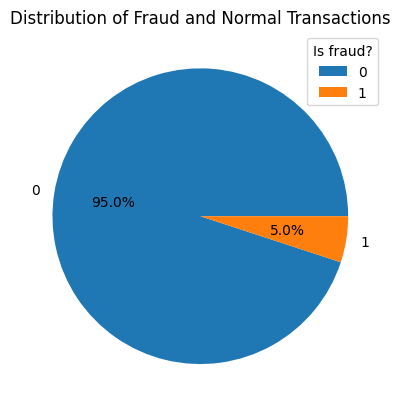

In [13]:
import seaborn as sns
import matplotlib.pyplot as plt
plt.pie(df['Is_Fraud'].value_counts(),labels=df['Is_Fraud'].unique(), autopct='%1.1f%%')
plt.title('Distribution of Fraud and Normal Transactions')
plt.legend(title = 'Is fraud?')
plt.show()

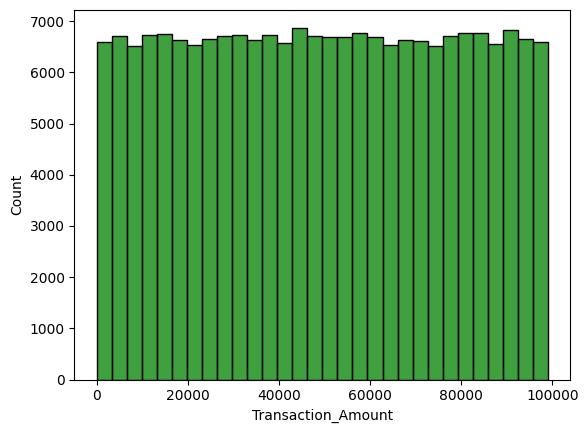

In [14]:

sns.histplot(df['Transaction_Amount'],bins=30,color='g')
plt.show()

### 4. Feature Analysis - Devices and Transaction Types

In [15]:
# See what types of transactions exist and how often they occur
print("Transaction Types:\n", df['Transaction_Type'].value_counts())

print("\n-------------------\n")

# See what devices are being used
print("Device Types:\n", df['Device_Type'].value_counts())

Transaction Types:
 Transaction_Type
Credit          40180
Debit           40050
Bill Payment    40040
Transfer        39953
Withdrawal      39777
Name: count, dtype: int64

-------------------

Device Types:
 Device_Type
POS        50111
ATM        50055
Mobile     49962
Desktop    49872
Name: count, dtype: int64


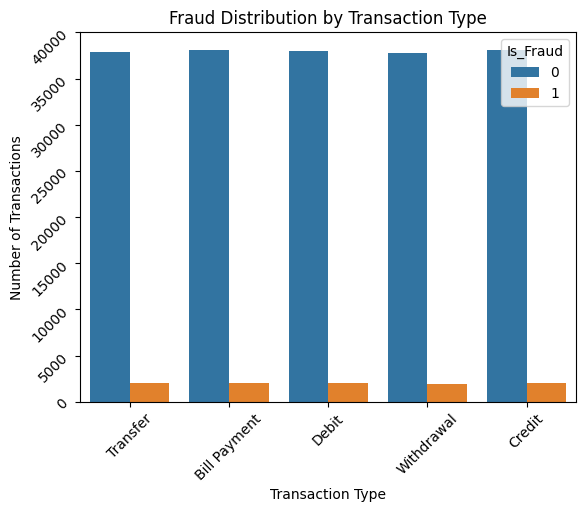

In [16]:
# Set up the visual style

sns.countplot(data=df, x='Transaction_Type', hue='Is_Fraud')
plt.title('Fraud Distribution by Transaction Type')
plt.xlabel('Transaction Type')
plt.ylabel('Number of Transactions')

plt.xticks(rotation=45)
plt.yticks(rotation=45)
plt.show()

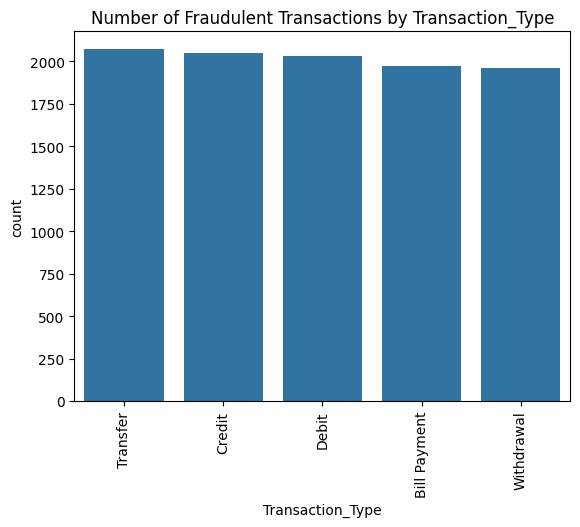

In [52]:
# Plot 2: Fraud by Transaction Type
fraud_data = df[df['Is_Fraud'] == 1]
sns.countplot(data=fraud_data, x='Transaction_Type', order=fraud_data['Transaction_Type'].value_counts().index)
plt.title('Number of Fraudulent Transactions by Transaction_Type')
plt.xticks(rotation=90)
plt.show()

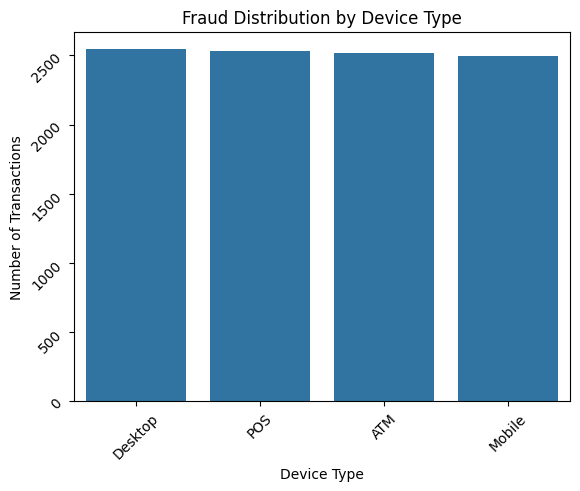

In [17]:
# Plot 2: Fraud by Device Type
frdata=df[df['Is_Fraud']==1]
sns.countplot(data=frdata, x='Device_Type', order=frdata['Device_Type'].value_counts().index)
plt.title('Fraud Distribution by Device Type')
plt.xlabel('Device Type')
plt.ylabel('Number of Transactions')

plt.xticks(rotation=45)
plt.yticks(rotation=45)
plt.show()

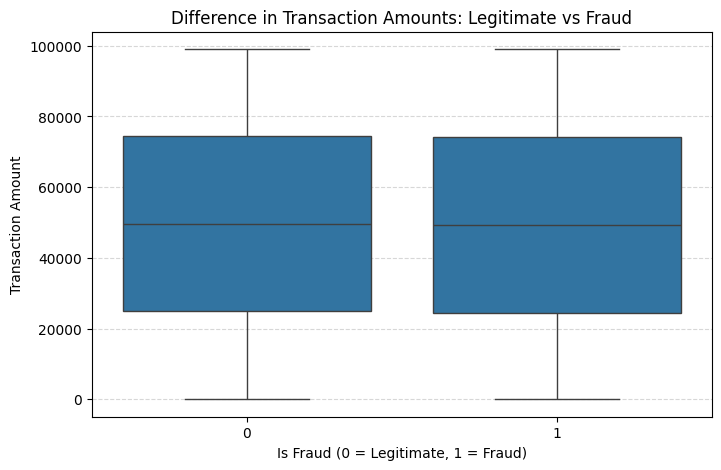

In [55]:
# Box plot for showing the spread of transaction amounts and identifying outliers
plt.figure(figsize=(8, 5))

# Using 'df' to compare both normal (0) and fraudulent (1) transactions
sns.boxplot(data=df, x='Is_Fraud', y='Transaction_Amount')

plt.title('Difference in Transaction Amounts: Legitimate vs Fraud')
plt.xlabel('Is Fraud (0 = Legitimate, 1 = Fraud)')
plt.ylabel('Transaction Amount')
plt.grid(True, linestyle='--', alpha=0.5, axis='y')

plt.show()

###  Feature Analysis - State(Location)

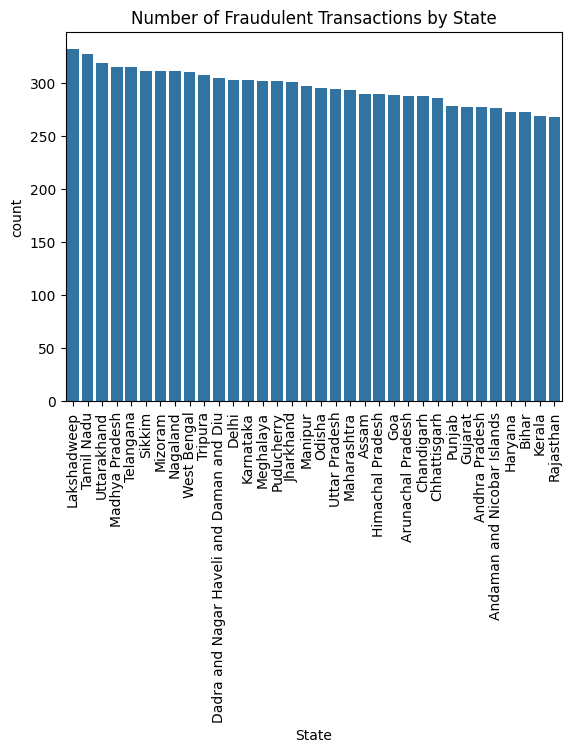

In [18]:

# Filter only fraudulent transactions to see where they happen most
fraud_data = df[df['Is_Fraud'] == 1]
sns.countplot(data=fraud_data, x='State', order=fraud_data['State'].value_counts().index)
plt.title('Number of Fraudulent Transactions by State')
plt.xticks(rotation=90)
plt.show()

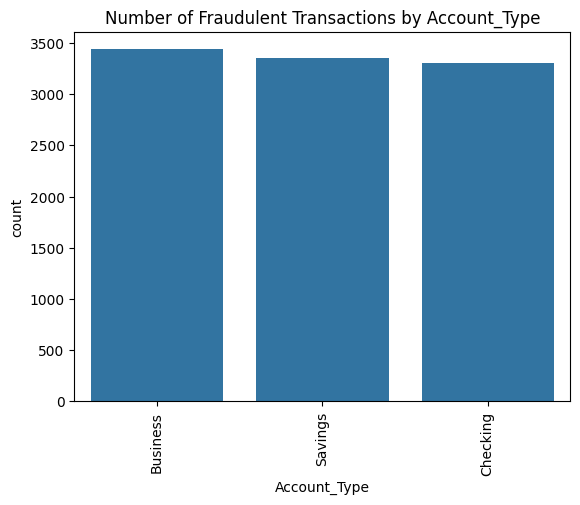

In [19]:
# Plot 2: Fraud by Account Type
fraud_data = df[df['Is_Fraud'] == 1]
sns.countplot(data=fraud_data, x='Account_Type', order=fraud_data['Account_Type'].value_counts().index)
plt.title('Number of Fraudulent Transactions by Account_Type')
plt.xticks(rotation=90)
plt.show()

Fraud Rate by Account Type:
 Account_Type
Business    0.051682
Savings     0.050291
Checking    0.049354
Name: Is_Fraud, dtype: float64


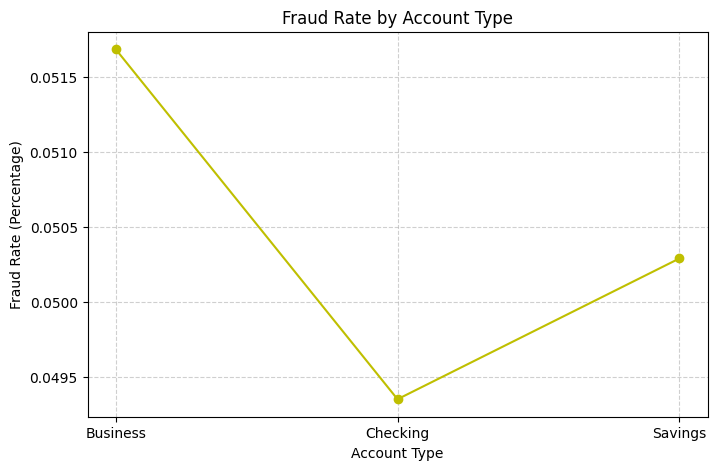

In [51]:
# Calculate fraud rate by Account Type using the main 'df'
frate_acc_type = df.groupby('Account_Type')['Is_Fraud'].mean()
print("Fraud Rate by Account Type:\n", frate_acc_type.sort_values(ascending=False))

# Plot the fraud rate by account type
plt.figure(figsize=(8, 5))
plt.plot(frate_acc_type.index, frate_acc_type.values, c='y', marker='o', ms=6)
plt.title('Fraud Rate by Account Type')
plt.xlabel('Account Type')
plt.ylabel('Fraud Rate (Percentage)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

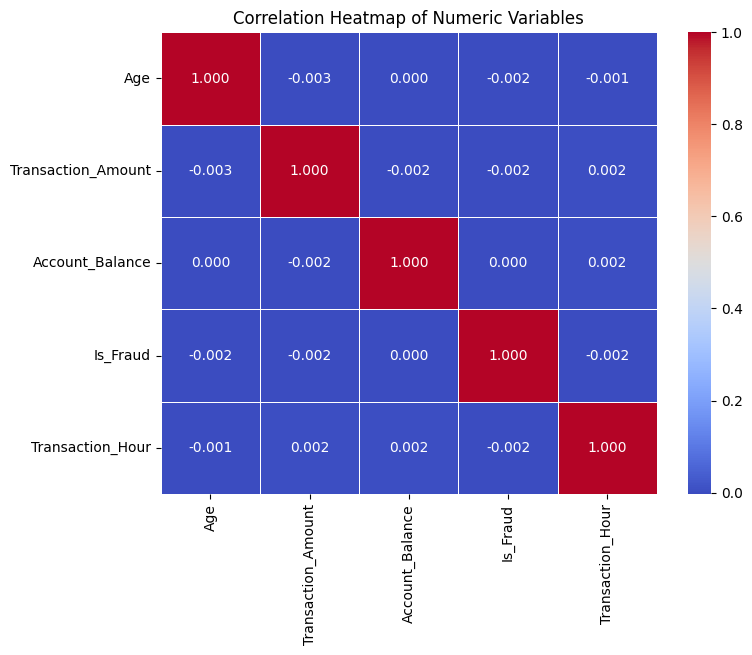

In [50]:
# Select only numeric columns for correlation (drops text columns automatically)
numeric_data = df.select_dtypes(include='number')

# Calculate the correlation matrix
corr = numeric_data.corr()

# Plot the heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(corr, cmap='coolwarm', annot=True, fmt=".3f", linewidths=0.5)
plt.title('Correlation Heatmap of Numeric Variables')
plt.show()

In [21]:
df.columns


Index(['Customer_ID', 'Gender', 'Age', 'State', 'City', 'Bank_Branch',
       'Account_Type', 'Transaction_ID', 'Transaction_Date',
       'Transaction_Time', 'Transaction_Amount', 'Merchant_ID',
       'Transaction_Type', 'Merchant_Category', 'Account_Balance',
       'Transaction_Device', 'Transaction_Location', 'Device_Type', 'Is_Fraud',
       'Transaction_Currency', 'Transaction_Description'],
      dtype='object')

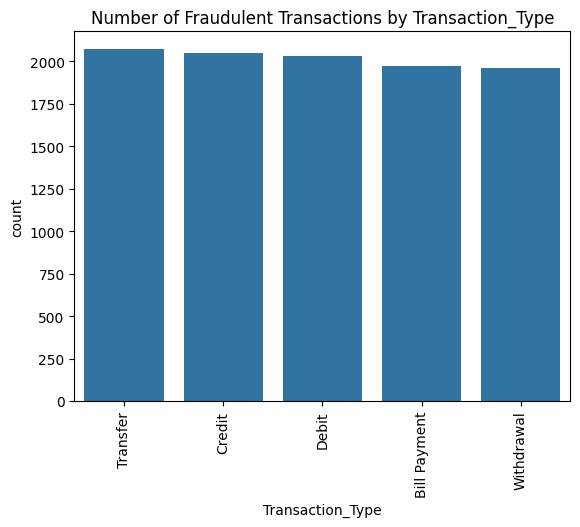

### Feature Analysis - Transaction Devices

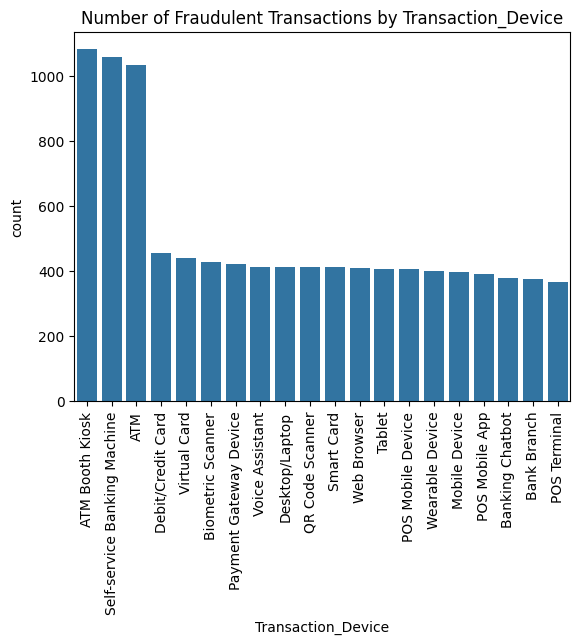

In [23]:
fraud_data = df[df['Is_Fraud'] == 1]
sns.countplot(data=fraud_data, x='Transaction_Device', order=fraud_data['Transaction_Device'].value_counts().index)
plt.title('Number of Fraudulent Transactions by Transaction_Device')
plt.xticks(rotation=90)
plt.show()

# 5. Feature Engineering - Time Based Risk

In [24]:
# Extract the exact hour of the transaction (0 to 23)
df['Transaction_Hour'] = df['Transaction_Time'].dt.hour

# Extract the day of the week (Monday, Tuesday, etc.)
df['Day_of_Week'] = df['Transaction_Date'].dt.day_name()

# Extract the month to see if certain months have spikes
df['Month'] = df['Transaction_Date'].dt.month_name()

# Verify the new columns were added
df[['Transaction_Time', 'Transaction_Hour', 'Transaction_Date', 'Day_of_Week', 'Month']].head()

,Transaction_Time,Transaction_Hour,Transaction_Date,Day_of_Week,Month
0,1900-01-01 16:04:07,16,2025-01-23,Thursday,January
1,1900-01-01 17:14:53,17,2025-01-11,Saturday,January
2,1900-01-01 03:09:52,3,2025-01-25,Saturday,January
3,1900-01-01 12:27:02,12,2025-01-19,Sunday,January
4,1900-01-01 18:30:46,18,2025-01-30,Thursday,January


# 6. Visualizing Fraud Across Time

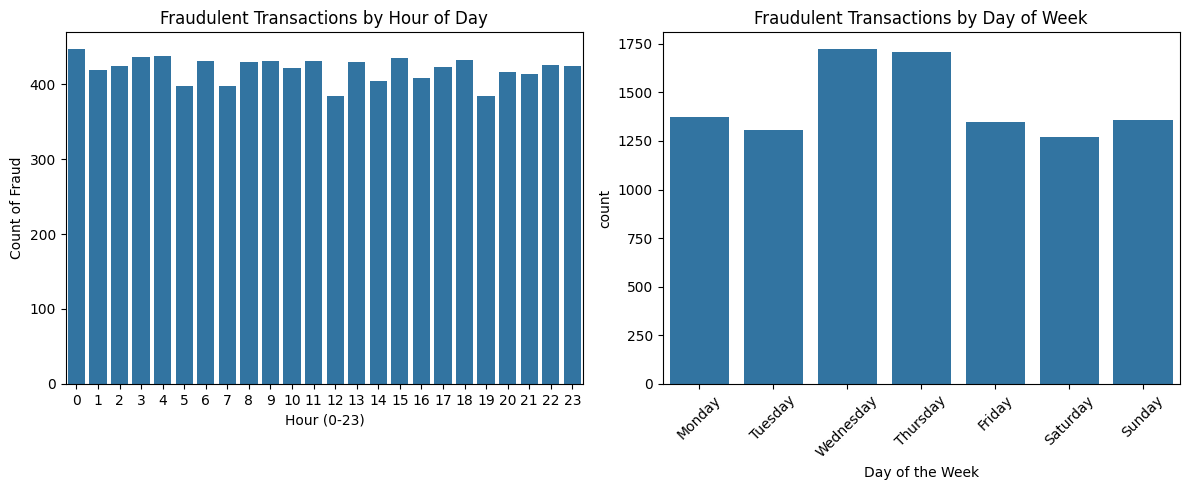

In [25]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 5))

# Plot 1: Fraud by Hour
plt.subplot(1, 2, 1)
sns.countplot(data=df[df['Is_Fraud'] == 1], x='Transaction_Hour')
plt.title('Fraudulent Transactions by Hour of Day')
plt.xlabel('Hour (0-23)')
plt.ylabel('Count of Fraud')

# Plot 2: Fraud by Day of Week
plt.subplot(1, 2, 2)
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
sns.countplot(data=df[df['Is_Fraud'] == 1], x='Day_of_Week', order=day_order)
plt.title('Fraudulent Transactions by Day of Week')
plt.xlabel('Day of the Week')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

Fraud Rate by Hour:
 Transaction_Hour
0     0.053221
9     0.052845
4     0.052651
3     0.052347
18    0.052080
Name: Is_Fraud, dtype: float64


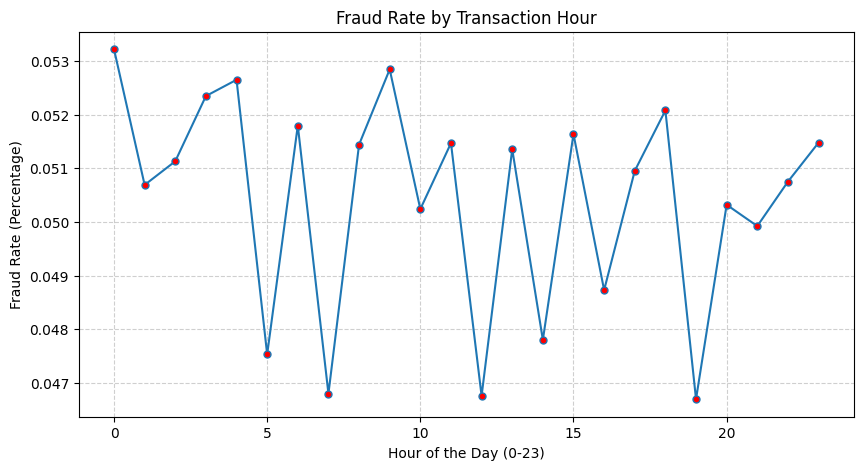

In [49]:
# Calculate fraud rate by hour using the main 'df'
fraud_rate_by_hour = df.groupby('Transaction_Hour')['Is_Fraud'].mean()
print("Fraud Rate by Hour:\n", fraud_rate_by_hour.sort_values(ascending=False).head())

# Plot the trend
plt.figure(figsize=(10, 5))
plt.plot(fraud_rate_by_hour.index, fraud_rate_by_hour.values, marker='o', ms=5, mfc='r')
plt.title('Fraud Rate by Transaction Hour')
plt.xlabel('Hour of the Day (0-23)')
plt.ylabel('Fraud Rate (Percentage)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

In [26]:
# Save the cleaned dataset to a new CSV file on your computer
df.to_csv("Cleaned_Bank_Transactions.csv", index=False)


# 8.  Risk Classification Modeling (Machine Learning)

In [40]:
!pip install scikit-learn

ERROR! Session/line number was not unique in database. History logging moved to new session 18



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [41]:
# Import the necessary Machine Learning libraries

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score
from sklearn.preprocessing import LabelEncoder

In [42]:
# 1. Prepare the data for ML
# Machine learning algorithms need numbers, not text. We will convert text columns to numbers.
ml_df = df.copy()

le = LabelEncoder()
text_columns = ['Transaction_Type', 'Device_Type', 'State']

for col in text_columns:
    ml_df[col] = le.fit_transform(ml_df[col].astype(str))
    
print("Text columns successfully converted to numbers!")

Text columns successfully converted to numbers!


In [43]:
# 2. Define Features (X) and Target (y)
# X = The data we use to make the guess (Amount, Hour, Type, Device, State)
# y = The answer we are trying to guess (Is_Fraud)

X = ml_df[['Transaction_Amount', 'Transaction_Hour', 'Transaction_Type', 'Device_Type', 'State']]
y = ml_df['Is_Fraud']

# 3. Train/Test Split
# We give the model 80% of the data to learn from, and keep 20% hidden to test it later.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training data size: {X_train.shape}")
print(f"Testing data size: {X_test.shape}")

Training data size: (160000, 5)
Testing data size: (40000, 5)


In [45]:
# 4. Build and Train the Random Forest Model
# This might take a few seconds to run because it is analyzing 160,000 rows!
model = RandomForestClassifier(n_estimators=50, random_state=42)
model.fit(X_train, y_train)

print("Model successfully trained!")

Model successfully trained!


In [46]:
# 5. Make Predictions and Evaluate
# Now we ask the model to guess the answers for the hidden 20% of data
predictions = model.predict(X_test)

# Print out the "Report Card" to see how well it did
print("Model Accuracy:", accuracy_score(y_test, predictions))
print("\nClassification Report:\n", classification_report(y_test, predictions))

Model Accuracy: 0.94495

Classification Report:
               precision    recall  f1-score   support

           0       0.95      1.00      0.97     37955
           1       0.02      0.00      0.00      2045

    accuracy                           0.94     40000
   macro avg       0.48      0.50      0.49     40000
weighted avg       0.90      0.94      0.92     40000

